In [1]:
# Multi Layer Perceptron으로 손글씨 분류

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
digits = load_digits()
# digits는 0~9까지 숫자를 손으로 쓴 이미지 데이터임
# 이미지는 0~15 명암 가지는 8x8 픽셀 흑백 이미지
# 이미지 1797개

In [3]:
print(digits.images[0]) # 0번의 이미지 출력

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


In [4]:
print(digits.target[0]) # 0번의 이미지가 무엇인지 label 확인

0


In [5]:
print('전체 샘플 수 : {}'.format(len(digits.images)))

전체 샘플 수 : 1797


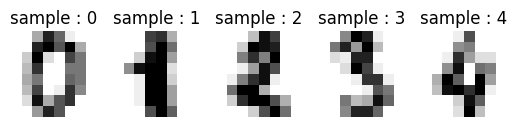

In [6]:
# 상위 5개 샘플만 시각화 함
images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:5]):
    plt.subplot(2,5,index + 1)
    plt.axis('off')
    plt.imshow(image, cmap = plt.cm.gray_r, interpolation = 'nearest')
    plt.title('sample : %i' % label)

In [7]:
for i in range(5):
    print(i, '번 인덱스 샘플의 레이블', digits.target[i])

0 번 인덱스 샘플의 레이블 0
1 번 인덱스 샘플의 레이블 1
2 번 인덱스 샘플의 레이블 2
3 번 인덱스 샘플의 레이블 3
4 번 인덱스 샘플의 레이블 4


In [8]:
print(digits.data[0]) # 8x8 matrix가 아니라 64차원 vector으로 출력

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


In [9]:
X = digits.data # 이미지
Y = digits.target # 레이블

In [10]:
import torch
import torch.nn as nn
from torch import optim

In [11]:
# 정리
# input data는 64차원의 vector임
# output형태는 10개가 나와야함. 0~9 의 숫자를 분류해야하기 때문

In [12]:
model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32,16),
    nn.ReLU(),
    nn.Linear(16, 10),
)

In [13]:
X = torch.tensor(X, dtype = torch.float32)
Y = torch.tensor(Y, dtype = torch.int64)

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())
losses = []

In [15]:
for epoch in range(100):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = loss_fn(y_pred, Y)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print('Epoch {:4d}/{} cost : {:.6f}'.format(
            epoch, 100, loss.item()
        ))

    losses.append(loss.item())

Epoch    0/100 cost : 2.559587
Epoch   10/100 cost : 2.143722
Epoch   20/100 cost : 1.847228
Epoch   30/100 cost : 1.485229
Epoch   40/100 cost : 1.097124
Epoch   50/100 cost : 0.747641
Epoch   60/100 cost : 0.511502
Epoch   70/100 cost : 0.370495
Epoch   80/100 cost : 0.285139
Epoch   90/100 cost : 0.230257


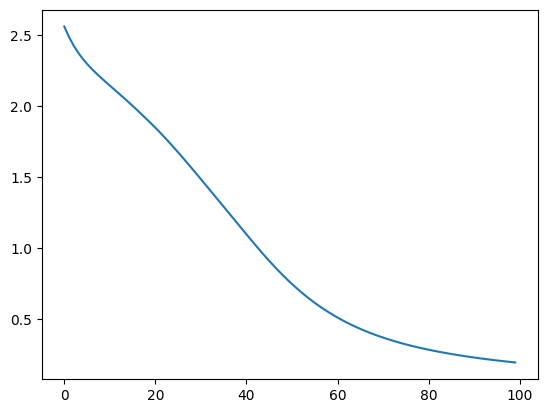

In [16]:
plt.plot(losses)

In [17]:
# 평가 (모델 성능 테스트)
from sklearn.model_selection import train_test_split

# 데이터 분할: 학습 80%, 테스트 20%
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=777)

print(f'학습 데이터: {len(X_train)}, 테스트 데이터: {len(X_test)}')

# 모델 평가 모드
model.eval()

# 테스트 데이터로 예측
with torch.no_grad():
    y_pred_test = model(X_test)
    correct = (y_pred_test.argmax(1) == Y_test).sum().item()
    accuracy = 100.0 * correct / len(Y_test)

print(f'\n테스트 정확도 : {accuracy:.2f}%')

# 학습 모드로 복귀 (필요시)
model.train()

# 훈련 정확도도 확인 (비교용)
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train)
    correct_train = (y_pred_train.argmax(1) == Y_train).sum().item()
    accuracy_train = 100.0 * correct_train / len(Y_train)

print(f'훈련 정확도 : {accuracy_train:.2f}%')
model.train()

학습 데이터: 1437, 테스트 데이터: 360

테스트 정확도 : 95.83%
훈련 정확도 : 95.82%


Sequential(
  (0): Linear(in_features=64, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=10, bias=True)
)